# Load dataset

In [ ]:
diabetes <- read.csv("diabetes.csv")

# Split dataset (80:20)

In [ ]:
set.seed(123) # Set Seed
# Train on 'diabetes' (want same results for class & global)
train_idx <- sample(1:nrow(diabetes), size = 0.8 * nrow(diabetes))

# Make copies of dataset after Split
  # Global
train_global <- diabetes[train_idx, ]
test_global <- diabetes[-train_idx, ]
  # Class
train_class <- diabetes[train_idx, ]
test_class <- diabetes[-train_idx, ]

# Calculate Means

In [ ]:
cols <- c("Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI") # Get 0-value columns
global_means <- sapply(cols, function(col) {mean(train_global[[col]][train_global[[col]] != 0])}) # Calculate means on TRAIN ONLY

for(col in cols){train_global[[col]][train_global[[col]] == 0] <- global_means[col]} # Replace 0's in TRAIN
for(col in cols){test_global[[col]][test_global[[col]] == 0] <- global_means[col]} # Replace 0's in TEST

In [ ]:
# TRAIN
  # Compute/Impute
# Insulin
mean_insulin_0 <- mean(train_class$Insulin[train_class$Outcome == 0 & train_class$Insulin != 0]) # When Outcome = 0 (Compute)
train_class$Insulin[train_class$Outcome == 0 & train_class$Insulin == 0] <- mean_insulin_0 # (Impute)
mean_insulin_1 <- mean(train_class$Insulin[train_class$Outcome == 1 & train_class$Insulin != 0]) # When Outcome = 1
train_class$Insulin[train_class$Outcome == 1 & train_class$Insulin == 0] <- mean_insulin_1

# Blood Pressure
mean_bp_0 <- mean(train_class$BloodPressure[train_class$Outcome == 0 & train_class$BloodPressure != 0])
train_class$BloodPressure[train_class$Outcome == 0 & train_class$BloodPressure == 0] <- mean_bp_0
mean_bp_1 <- mean(train_class$BloodPressure[train_class$Outcome == 1 & train_class$BloodPressure != 0])
train_class$BloodPressure[train_class$Outcome == 1 & train_class$BloodPressure == 0] <- mean_bp_1

# BMI
mean_bmi_0 <- mean(train_class$BMI[train_class$Outcome == 0 & train_class$BMI != 0])
train_class$BMI[train_class$Outcome == 0 & train_class$BMI == 0] <- mean_bmi_0
mean_bmi_1 <- mean(train_class$BMI[train_class$Outcome == 1 & train_class$BMI != 0])
train_class$BMI[train_class$Outcome == 1 & train_class$BMI == 0] <- mean_bmi_1

# Glucose
mean_glucose_0 <- mean(train_class$Glucose[train_class$Outcome == 0 & train_class$Glucose != 0])
train_class$Glucose[train_class$Outcome == 0 & train_class$Glucose == 0] <- mean_glucose_0
mean_glucose_1 <- mean(train_class$Glucose[train_class$Outcome == 1 & train_class$Glucose != 0])
train_class$Glucose[train_class$Outcome == 1 & train_class$Glucose == 0] <- mean_glucose_1

# Skin Thickness
mean_skin_0 <- mean(train_class$SkinThickness[train_class$Outcome == 0 & train_class$SkinThickness != 0])
train_class$SkinThickness[train_class$Outcome == 0 & train_class$SkinThickness == 0] <- mean_skin_0
mean_skin_1 <- mean(train_class$SkinThickness[train_class$Outcome == 1 & train_class$SkinThickness != 0])
train_class$SkinThickness[train_class$Outcome == 1 & train_class$SkinThickness == 0] <- mean_skin_1

In [ ]:
# TEST
  # Impute
test_class$Insulin[test_class$Outcome == 0 & test_class$Insulin == 0] <- mean_insulin_0
test_class$Insulin[test_class$Outcome == 1 & test_class$Insulin == 0 ] <- mean_insulin_1

test_class$BloodPressure[test_class$Outcome == 0 & test_class$BloodPressure == 0] <- mean_bp_0
test_class$BloodPressure[test_class$Outcome == 1 & test_class$BloodPressure == 0 ] <- mean_bp_1

test_class$BMI[test_class$Outcome == 0 & test_class$BMI == 0] <- mean_bmi_0
test_class$BMI[test_class$Outcome == 1 & test_class$BMI == 0 ] <- mean_bmi_1

test_class$Glucose[test_class$Outcome == 0 & test_class$Glucose == 0] <- mean_glucose_0
test_class$Glucose[test_class$Outcome == 1 & test_class$Glucose == 0 ] <- mean_glucose_1

test_class$SkinThickness[test_class$Outcome == 0 & test_class$SkinThickness == 0] <- mean_skin_0
test_class$SkinThickness[test_class$Outcome == 1 & test_class$SkinThickness == 0 ] <- mean_skin_1

# Diagnostics (Before Training SVM)

In [ ]:
# Diagnostics
names(train_class)
str(train_class)
table(train_class$Outcome)
dim(train_class)
cat("\n")
svm_model$bestTune

[1] "Pregnancies"              "Glucose"                 
[3] "BloodPressure"            "SkinThickness"           
[5] "Insulin"                  "BMI"                     
[7] "DiabetesPedigreeFunction" "Age"                     
[9] "Outcome"

'data.frame':	614 obs. of  9 variables:
 $ Pregnancies             : int  0 8 5 3 8 5 14 4 6 1 ...
 $ Glucose                 : num  138 74 143 87 85 78 100 197 119 189 ...
 $ BloodPressure           : num  60 70 78 60 55 48 78 70 50 60 ...
 $ SkinThickness           : num  35 40 27.3 18 20 ...
 $ Insulin                 : num  167 49 129 129 129 ...
 $ BMI                     : num  34.6 35.3 45 21.8 24.4 33.7 36.6 36.7 27.1 30.1 ...
 $ DiabetesPedigreeFunction: num  0.534 0.705 0.19 0.444 0.136 ...
 $ Age                     : int  21 39 47 21 42 25 46 31 33 59 ...
 $ Outcome                 : int  1 0 0 0 0 0 1 0 1 1 ...



  0   1 
398 216 

[1] 614   9

,sigma,C
,<dbl>,<dbl>
8,0.01,5


# SVM

In [ ]:
# Install package(s) for SVM
  # Will take a few minutes to load (10)
install.packages("e1071")
install.packages("caret")
install.packages("kernlab")
library(e1071)
library(caret)
library(kernlab)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice


Attaching package: ‘kernlab’


The following object is masked from ‘package:ggplot2’:

    alpha




    Tuned SVM

In [ ]:
train_class$Outcome <- as.factor(train_class$Outcome)
test_class$Outcome  <- as.factor(test_class$Outcome)

In [ ]:
ctrl <- trainControl(method = "cv", number = 10, classProbs = TRUE, summaryFunction = twoClassSummary)
  # cv : 10-fold cross validation

In [ ]:
train_class$Outcome <- factor(train_class$Outcome, levels = c(0, 1), labels = c("No", "Yes"))
test_class$Outcome <- factor(test_class$Outcome, levels = c(0, 1), labels = c("No", "Yes"))
  # Binary (0 & 1)

In [ ]:
grid <- expand.grid(sigma = c(0.001, 0.01, 0.05, 0.1, 0.5), C = c(0.1, 1, 5, 10, 20))
  # Tuning space (aka Test combinations)

,sigma,C
,<dbl>,<dbl>
8,0.01,5


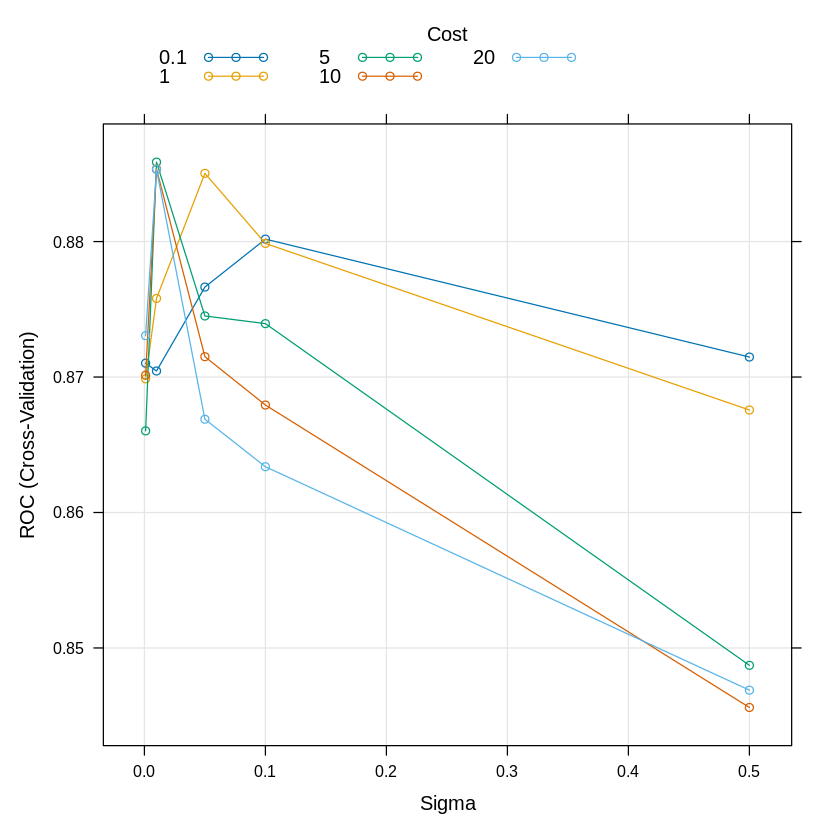

In [ ]:
# Tuned SVM
svm_model <- train(
  Outcome ~ .,
  data = train_class,
  method = "svmRadial",
  metric = "ROC",
  trControl = ctrl,
  preProcess = c("center", "scale"),
  tuneGrid = grid
)
# Inspect best model
svm_model$bestTune # The sigma and C that produced the highest ROC score
plot(svm_model)
  # X-axis: sigma or C
  # Y-axis: ROC performance

In [ ]:
# Predict on test set
pred <- predict(svm_model, newdata = test_class)
# Confusion matrix
confusionMatrix(pred, test_class$Outcome)

Confusion Matrix and Statistics

          Reference
Prediction No Yes
       No  91  16
       Yes 11  36
                                          
               Accuracy : 0.8247          
                 95% CI : (0.7553, 0.8812)
    No Information Rate : 0.6623          
    P-Value [Acc > NIR] : 5.539e-06       
                                          
                  Kappa : 0.5986          
                                          
 Mcnemar's Test P-Value : 0.4414          
                                          
            Sensitivity : 0.8922          
            Specificity : 0.6923          
         Pos Pred Value : 0.8505          
         Neg Pred Value : 0.7660          
             Prevalence : 0.6623          
         Detection Rate : 0.5909          
   Detection Prevalence : 0.6948          
      Balanced Accuracy : 0.7922          
                                          
       'Positive' Class : No              
                                 

In [ ]:
train_global$Outcome <- factor(
    train_global$Outcome,
    levels = c(0,1),
    labels = c("No","Yes")
)

test_global$Outcome <- factor(
    test_global$Outcome,
    levels = c(0,1),
    labels = c("No","Yes")
)

    Linear Kernel

In [ ]:
# UNSCALED - Class
  # "Using ALL predictors except Cluster"


# Remove Outcome and Cluster
Xc_train_unscaled <- train_class[
    ,
    !(names(train_class) %in% c("Outcome", "Cluster"))
]

Xc_test_unscaled <- test_class[
    ,
    !(names(test_class) %in% c("Outcome", "Cluster"))
]

train_class_linear <- data.frame(
    Outcome = train_class$Outcome,
    Xc_train_unscaled
)

test_class_linear <- data.frame(
    Outcome = test_class$Outcome,
    Xc_test_unscaled
)

svm_class_linear <- svm(
    Outcome ~ .,
    data = train_class_linear,
    kernel = "linear"
)

pred_class_linear <- predict(
    svm_class_linear,
    newdata = test_class_linear
)

mean(pred_class_linear == test_class_linear$Outcome)

table(
    Predicted = pred_class_linear,
    Actual = test_class_linear$Outcome
)

[1] 0.8181818

         Actual
Predicted No Yes
      No  90  16
      Yes 12  36

In [ ]:
svm_class_linear


Call:
svm(formula = Outcome ~ ., data = train_class_linear, kernel = "linear")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  linear 
       cost:  1 

Number of Support Vectors:  294


In [ ]:
# SCALED - Class


Xc_train_scaled <- scale(Xc_train_unscaled)

Xc_test_scaled <- scale(
    Xc_test_unscaled,
    center = attr(Xc_train_scaled, "scaled:center"),
    scale = attr(Xc_train_scaled, "scaled:scale")
)

train_class_linear_scaled <- data.frame(
    Outcome = train_class$Outcome,
    Xc_train_scaled
)

test_class_linear_scaled <- data.frame(
    Outcome = test_class$Outcome,
    Xc_test_scaled
)

svm_class_linear_scaled <- svm(
    Outcome ~ .,
    data = train_class_linear_scaled,
    kernel = "linear"
)

pred_class_linear_scaled <- predict(
    svm_class_linear_scaled,
    newdata = test_class_linear_scaled
)

mean(pred_class_linear_scaled ==
     test_class_linear_scaled$Outcome)

table(
    Predicted = pred_class_linear_scaled,
    Actual = test_class_linear_scaled$Outcome
)

[1] 0.8181818

         Actual
Predicted No Yes
      No  90  16
      Yes 12  36

    Radial Kernel

    CLASS

In [ ]:
# UNSCALED
Xc_train_unscaled <- train_class[
    ,
    !(names(train_class) %in% c("Outcome", "Cluster"))
]
Xc_test_unscaled <- test_class[
    ,
    !(names(test_class) %in% c("Outcome", "Cluster"))
]

train_class_unscaled <- data.frame(
    Outcome = as.factor(train_class$Outcome),
    Xc_train_unscaled
)
test_class_unscaled <- data.frame(
    Outcome = as.factor(test_class$Outcome),
    Xc_test_unscaled
)

svm_class_radial <- svm(
    Outcome ~ .,
    data = train_class_unscaled,
    kernel = "radial"
)
pred_class_radial <- predict(
    svm_class_radial,
    newdata = test_class_unscaled
)


mean(pred_class_radial == test_class_unscaled$Outcome)
table(
    Predicted = pred_class_radial,
    Actual = test_class_unscaled$Outcome
)

[1] 0.8636364

         Actual
Predicted No Yes
      No  93  12
      Yes  9  40

In [ ]:
svm_class_radial


Call:
svm(formula = Outcome ~ ., data = train_class_unscaled, kernel = "radial")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  307


In [ ]:
# SCALED
Xc_train_scaled <- scale(Xc_train_unscaled)
Xc_test_scaled <- scale(
    Xc_test_unscaled,
    center = attr(Xc_train_scaled, "scaled:center"),
    scale = attr(Xc_train_scaled, "scaled:scale")
)

train_class_scaled <- data.frame(
    Outcome = as.factor(train_class$Outcome),
    Xc_train_scaled
)
test_class_scaled <- data.frame(
    Outcome = as.factor(test_class$Outcome),
    Xc_test_scaled
)

svm_class_radial_scaled <- svm(
    Outcome ~ .,
    data = train_class_scaled,
    kernel = "radial"
)
pred_class_radial_scaled <- predict(
    svm_class_radial_scaled,
    newdata = test_class_scaled
)


mean(pred_class_radial_scaled ==
     test_class_scaled$Outcome)
table(
    Predicted = pred_class_radial_scaled,
    Actual = test_class_scaled$Outcome
)

[1] 0.8636364

         Actual
Predicted No Yes
      No  93  12
      Yes  9  40

# SVM - Plots

    Decision Boundary

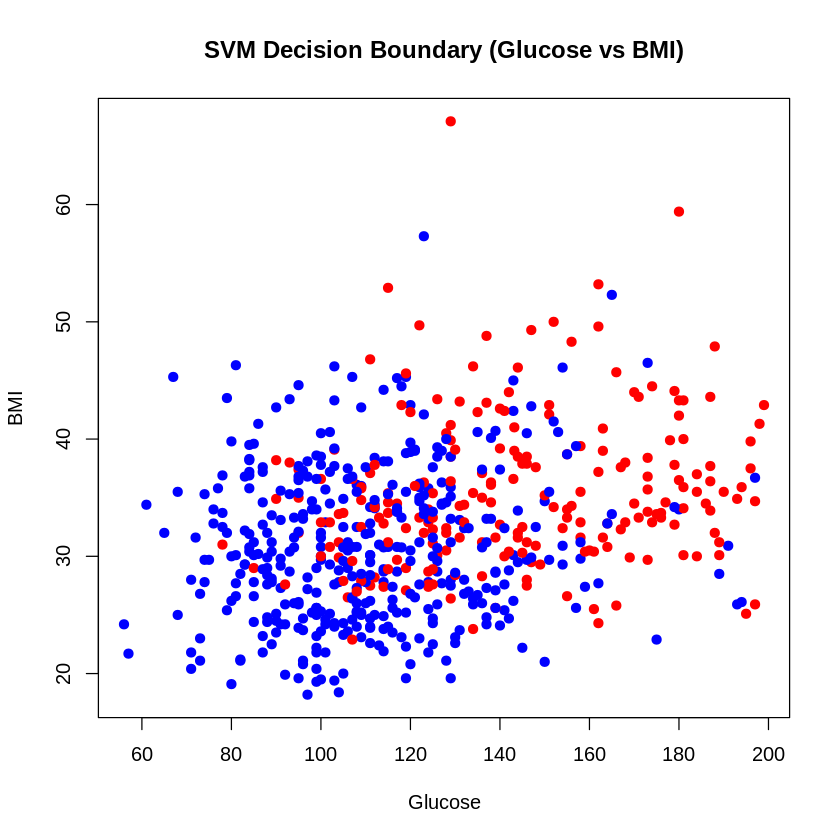

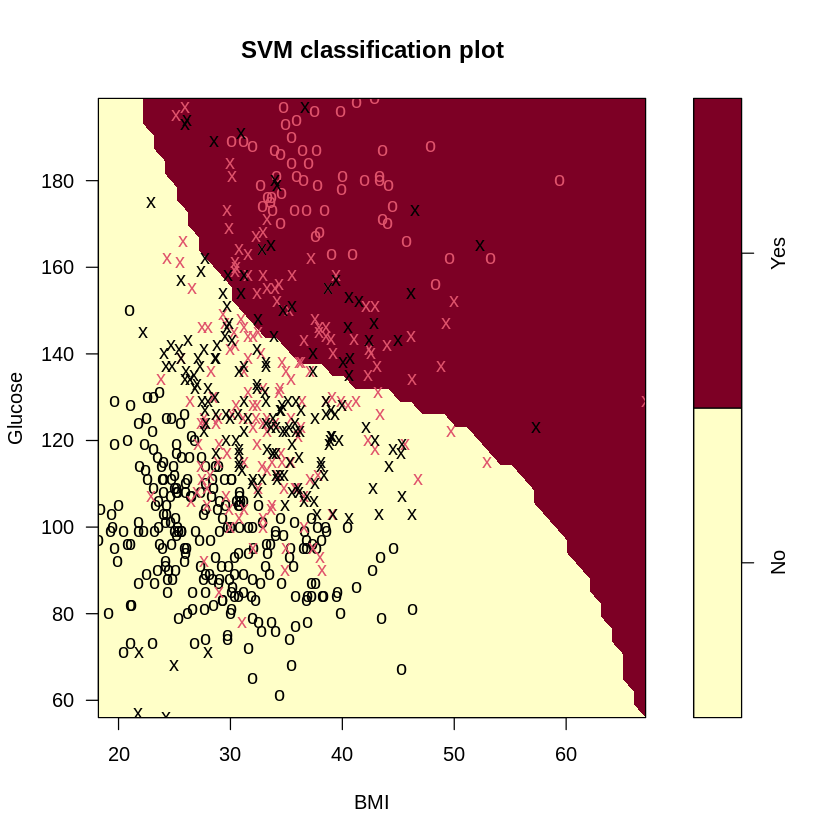

In [ ]:
# 2D
  # Glucose and BMI
    # Better predictors (?)
viz_train <- data.frame(
  Glucose = train_class$Glucose,
  BMI = train_class$BMI,
  Outcome = train_class$Outcome
)

# Train
svm_viz <- svm(
  Outcome ~ .,
  data = viz_train,
  kernel = "radial",
  cost = 1,
  gamma = 0.1,
  scale = TRUE
)

# Plot
plot(
  viz_train$Glucose,
  viz_train$BMI,
  col = ifelse(viz_train$Outcome == "Yes", "red", "blue"),
  pch = 19,
  xlab = "Glucose",
  ylab = "BMI",
  main = "SVM Decision Boundary (Glucose vs BMI)"
)

plot(svm_viz, viz_train)

    Scatter (PCA projection)

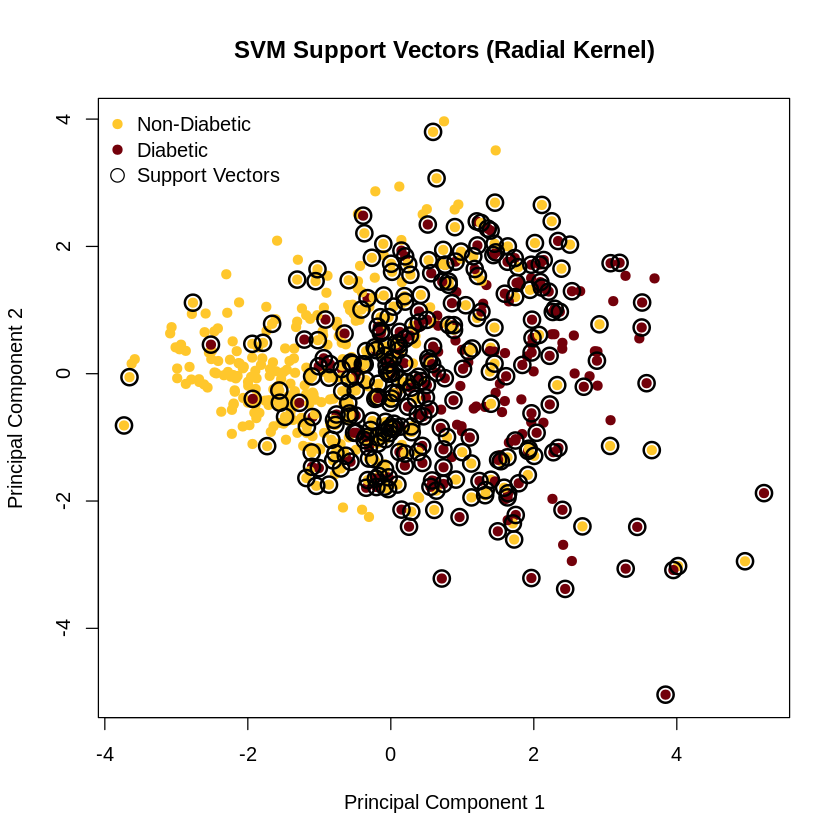

In [ ]:
# Using CLASS RADIAL

# PCA
pca_svm <- prcomp(Xc_train_scaled)
# Support Vectors
sv <- svm_class_radial_scaled$index
# (Colors)
colors <- c("#FFC72C", "#73000A")

# Plot
plot(
    pca_svm$x[,1],
    pca_svm$x[,2],
    col = ifelse(
        train_class$Outcome == "No",
        "#FFC72C",
        "#73000A"
    ),
    pch = 19,
    xlab = "Principal Component 1",
    ylab = "Principal Component 2",
    main = "SVM Support Vectors (Radial Kernel)"
)
# Highlight support vectors
  # On the margin, Inside the margin, Misclassified / hard cases
  # “The hardest, most informative points”
points(
    pca_svm$x[sv,1],
    pca_svm$x[sv,2],
    pch = 1,
    cex = 1.8,
    lwd = 2
)
# Legend
legend(
    "topleft",
    legend = c(
        "Non-Diabetic",
        "Diabetic",
        "Support Vectors"
    ),
    col = c(
        "#FFC72C",
        "#73000A",
        "black"
    ),
    pch = c(
        19,
        19,
        1
    ),
    pt.cex = c(
        1,
        1,
        1.5
    ),
    bty = "n"
)

    ROC

In [ ]:
install.packages("pROC")
library(pROC)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [ ]:
# Refit with probabilities enabled
#svm_class_radial_prob <- svm(
#    Outcome ~ .,
#    data = train_class_scaled,
#    kernel = "radial",
#    probability = TRUE
#)
# Predict Probabilites
#svm_pred <- predict(
#    svm_class_radial_prob,
#    newdata = test_class_scaled,
#    probability = TRUE
#)
#svm_prob <- attr(svm_pred, "probabilities")
#head(svm_prob)
#
# Create ROC curve
#roc_svm <- roc(
#    response = test_class_scaled$Outcome,
#    predictor = svm_prob[, "Yes"]
#)
#
# Plot
#plot(
#    roc_svm,
#    col = "#73000A",     # Garnet
#    lwd = 3,
#    main = "ROC Curve for SVM (Radial Kernel)"
#)
#abline(
#    a = 0,
#    b = 1,
#    lty = 2,
#    col = "#FFC72C"      # Gold
#)
# Area Under Curve
#auc(roc_svm)
#plot(
#    roc_svm,
#    col = "#73000A",
#    lwd = 3,
#    main = paste(
#        "ROC Curve for SVM (AUC =",
#        round(auc(roc_svm), 3),
#        ")"
#    )
#)
#
#abline(0, 1, lty = 2, col = "#FFC72C")

Setting levels: control = No, case = Yes

Setting direction: controls < cases



Area under the curve: 0.8842

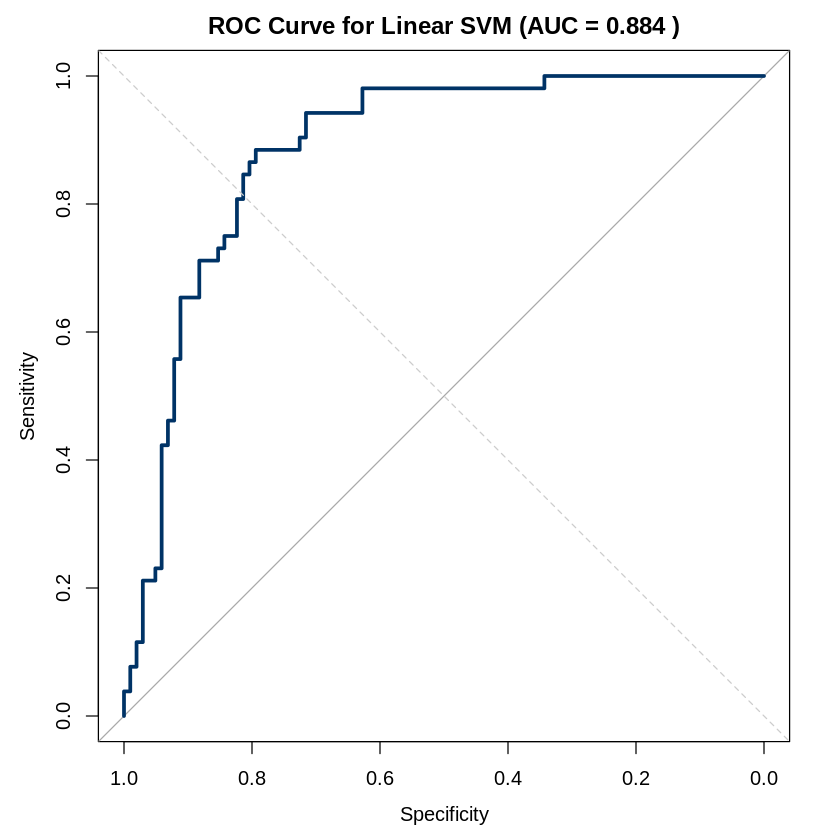

In [ ]:
# LINEAR


# Train Linear SVM with probabilities
svm_class_linear_prob <- svm(
    Outcome ~ .,
    data = train_class_linear_scaled,
    kernel = "linear",
    probability = TRUE
)

# Predict probabilities
linear_pred <- predict(
    svm_class_linear_prob,
    newdata = test_class_linear_scaled,
    probability = TRUE
)

linear_prob <- attr(linear_pred, "probabilities")

# ROC
roc_linear <- roc(
    response = test_class_linear_scaled$Outcome,
    predictor = linear_prob[, "Yes"]
)

# Plot
plot(
    roc_linear,
    col = "#003366",
    lwd = 3,
    main = paste(
        "ROC Curve for Linear SVM (AUC =",
        round(auc(roc_linear), 3),
        ")"
    )
)

abline(a = 0, b = 1, lty = 2, col = "#CCCCCC")

# AUC
auc(roc_linear)

Setting levels: control = No, case = Yes

Setting direction: controls < cases



Area under the curve: 0.9074

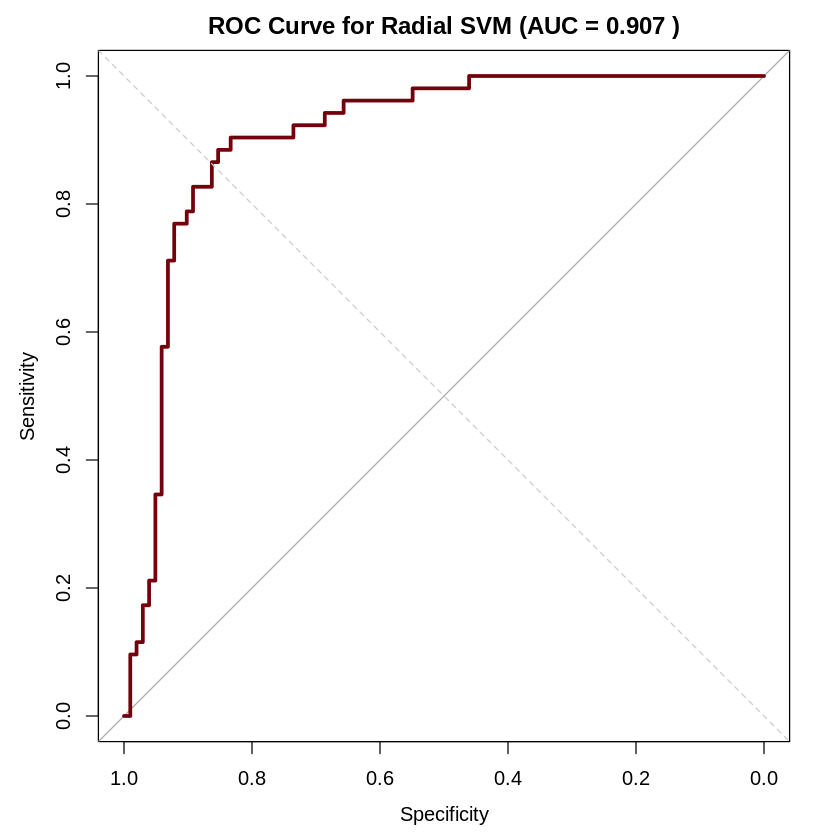

In [ ]:
# RADIAL


# Refit model (scaled recommended)
svm_class_radial_prob <- svm(
    Outcome ~ .,
    data = train_class_scaled,
    kernel = "radial",
    probability = TRUE
)

# Predict probabilities
svm_pred <- predict(
    svm_class_radial_prob,
    newdata = test_class_scaled,
    probability = TRUE
)

svm_prob <- attr(svm_pred, "probabilities")

# ROC curve
roc_svm <- roc(
    response = test_class_scaled$Outcome,
    predictor = svm_prob[, "Yes"]
)

# Plot
plot(
    roc_svm,
    col = "#73000A",
    lwd = 3,
    main = paste("ROC Curve for Radial SVM (AUC =", round(auc(roc_svm), 3), ")")
)

abline(a = 0, b = 1, lty = 2, col = "#CCCCCC")

# AUC
auc(roc_svm)

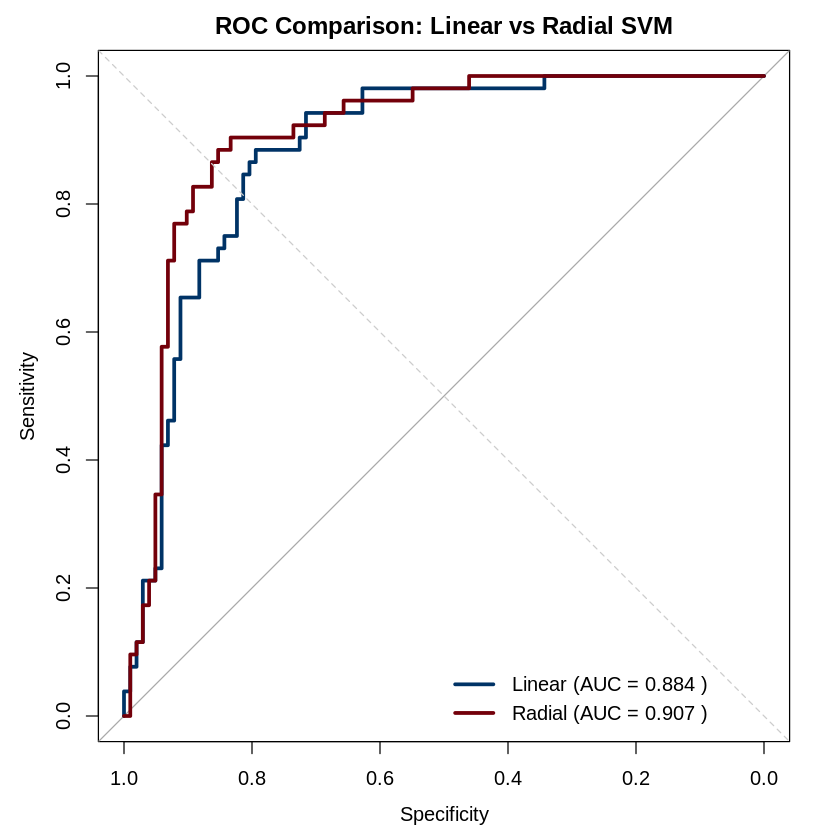

In [ ]:
# COMPARE


plot(
    roc_linear,
    col = "#003366",
    lwd = 3,
    main = "ROC Comparison: Linear vs Radial SVM"
)

plot(
    roc_svm,
    col = "#73000A",
    lwd = 3,
    add = TRUE
)

abline(a = 0, b = 1, lty = 2, col = "#CCCCCC")

legend(
    "bottomright",
    legend = c(
        paste("Linear (AUC =", round(auc(roc_linear), 3), ")"),
        paste("Radial (AUC =", round(auc(roc_svm), 3), ")")
    ),
    col = c("#003366", "#73000A"),
    lwd = 3,
    bty = "n"
)

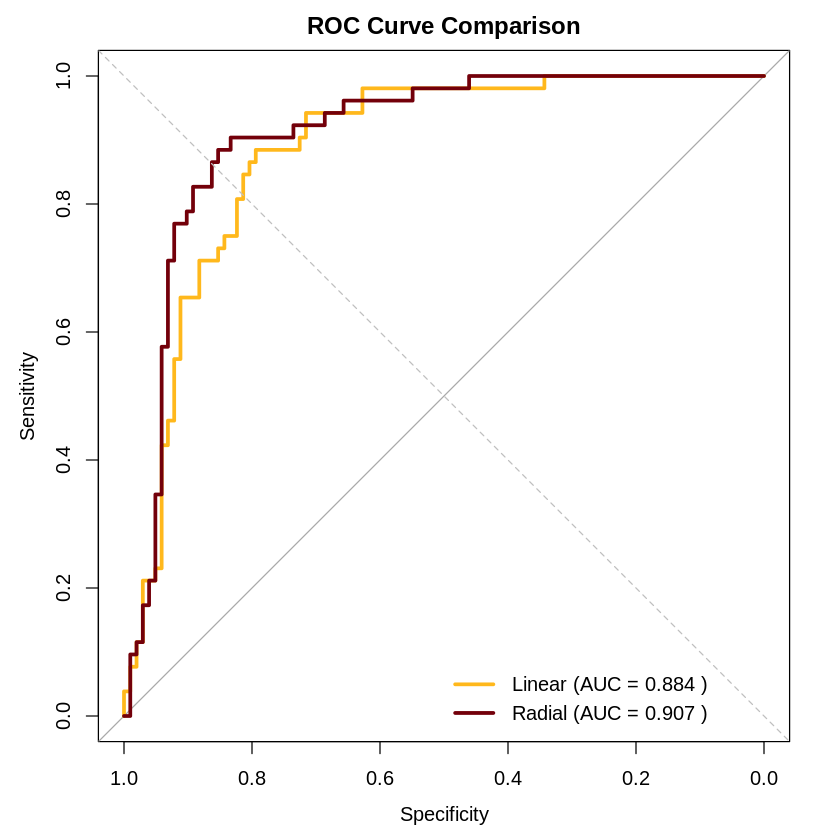

In [ ]:
plot(
    roc_linear,
    col = "#FFB81C",   # Gold
    lwd = 3,
    main = "ROC Curve Comparison"
)

plot(
    roc_svm,
    col = "#73000A",   # Garnet
    lwd = 3,
    add = TRUE
)

abline(a = 0, b = 1, lty = 2, col = "gray75")

legend(
    "bottomright",
    legend = c(
        paste("Linear (AUC =", round(auc(roc_linear), 3), ")"),
        paste("Radial (AUC =", round(auc(roc_svm), 3), ")")
    ),
    col = c("#FFB81C", "#73000A"),
    lwd = 3,
    bty = "n"
)

# KNN

In [ ]:
# Install packages
install.packages("class")
library(class)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Set-up/Prepare data
# Class Mean
  # Features/Target
Xc_train <- train_class[, names(train_class) != "Outcome"]
Xc_test <- test_class[, names(test_class) != "Outcome"]
Xc_train <- Xc_train[, names(Xc_train) != "Cluster"] # REMOVE Cluster if it exists
Xc_test <- Xc_test[, names(Xc_test) != "Cluster"] # # REMOVE Cluster if it exists
yc_train <- train_class$Outcome
yc_test <- test_class$Outcome
  # Scale
Xc_train_scaled <- scale(Xc_train)
Xc_test_scaled <- scale(Xc_test, center = attr(Xc_train_scaled, "scaled:center"), scale = attr(Xc_train_scaled, "scaled:scale"))

# Global Mean
Xg_train <- train_global[, names(train_global) != "Outcome"]
Xg_test  <- test_global[, names(test_global) != "Outcome"]
Xg_train <- Xg_train[, names(Xg_train) != "Cluster"]
Xg_test <- Xg_test[, names(Xg_test) != "Cluster"]
yg_train <- train_global$Outcome
yg_test <- test_global$Outcome
Xg_train_scaled <- scale(Xg_train)
Xg_test_scaled <- scale(Xg_test, center = attr(Xg_train_scaled, "scaled:center"), scale = attr(Xg_train_scaled, "scaled:scale"))

In [ ]:
# Tune K
k_values <- c(1,3,5,7,9,11,15)

# Class
acc_c <- sapply(k_values, function(k){
  pred <- knn(train = Xc_train_scaled, test = Xc_test_scaled, cl = yc_train, k = k)
  mean(pred == yc_test)
})
data.frame(k = k_values, accuracy = acc_c)
#data.frame(k = k_values, error = 1 - acc_c)

# Global
acc_g <- sapply(k_values, function(k){
  pred <- knn(train = Xg_train_scaled, test = Xg_test_scaled, cl = yg_train, k = k)
  mean(pred == yg_test)
})
data.frame(k = k_values, accuracy = acc_g)

k,accuracy
<dbl>,<dbl>
1,0.8376623
3,0.8636364
5,0.8701299
7,0.8636364
9,0.8441558
11,0.8246753
15,0.8376623


k,accuracy
<dbl>,<dbl>
1,0.7402597
3,0.7727273
5,0.7792208
7,0.7857143
9,0.7857143
11,0.7792208
15,0.8051948


# KNN - ROC Curve

In [ ]:
#install.packages("class")
install.packages("pROC")
#library(class)
library(pROC)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [ ]:
table(yc_test)
levels(yc_test)
str(yc_test)

yc_test
  0   1 
102  52 

NULL

 int [1:154] 1 1 1 1 0 1 0 1 0 0 ...


Setting direction: controls < cases



Area under the curve: 0.6858

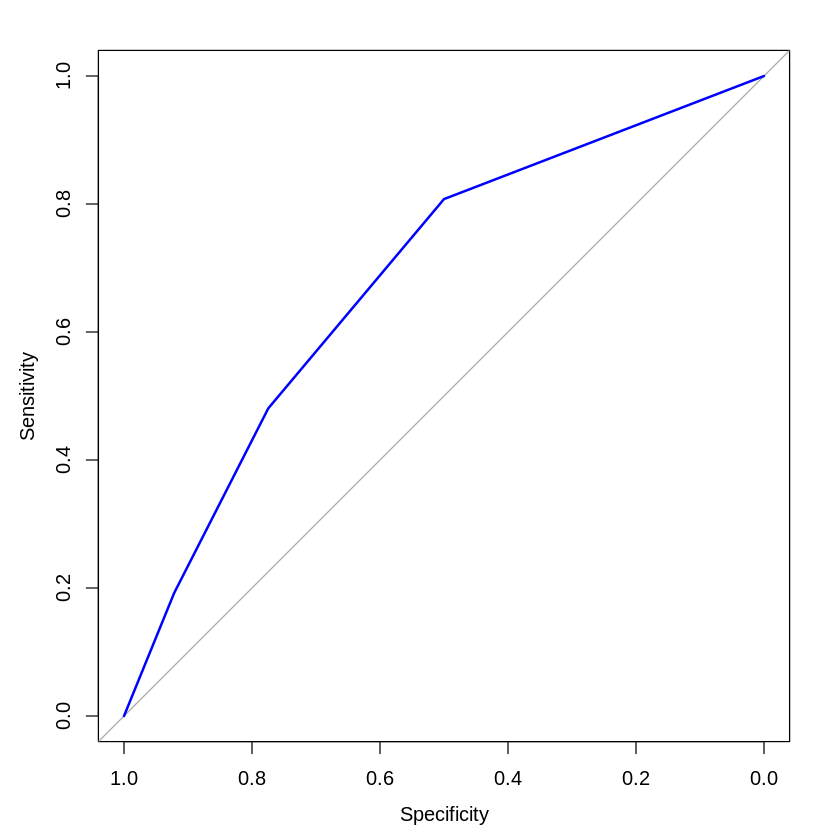

In [ ]:
# CLASS


pred <- knn(
  train = Xc_train_scaled,
  test = Xc_test_scaled,
  cl = yc_train,
  k = 7,          # your chosen k
  prob = TRUE
)

# Extract vote proportions
prob <- attr(pred, "prob")

# Convert to probability of the positive class
prob_yes <- ifelse(pred == "Yes", prob, 1 - prob)

roc_knn_class <- roc(
  response = yc_test,
  predictor = prob_yes,
  levels = c("0", "1")
)

plot(roc_knn_class, col = "blue", lwd = 2)
auc(roc_knn_class)

Setting direction: controls < cases



Area under the curve: 0.7205

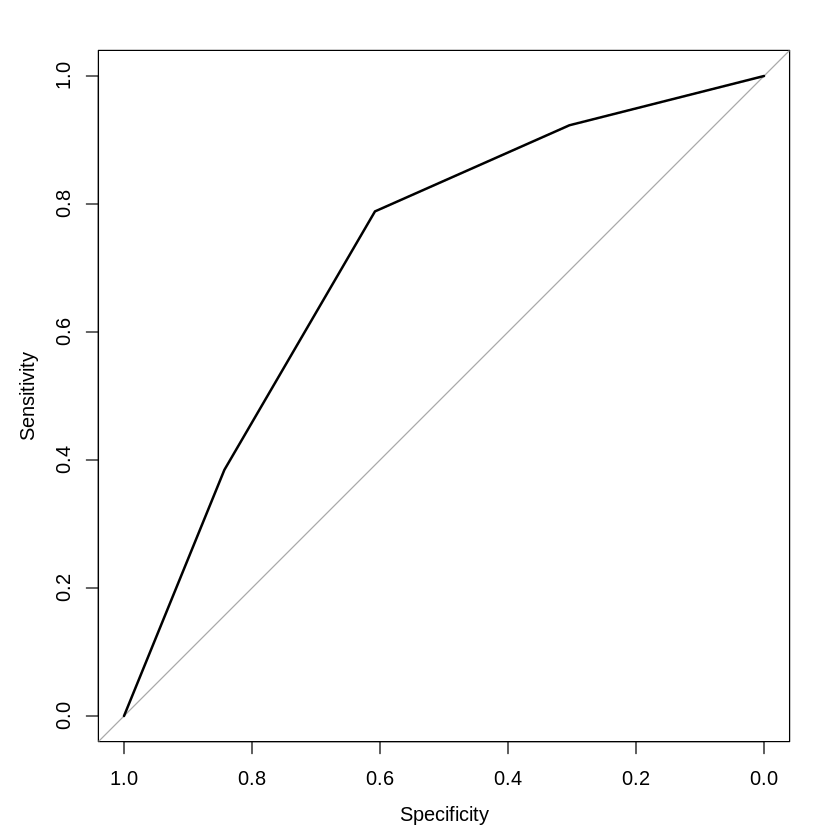

In [ ]:
# GLOBAL


pred <- knn(
  train = Xg_train_scaled,
  test = Xg_test_scaled,
  cl = yg_train,
  k = 7,
  prob = TRUE
)

prob <- attr(pred, "prob")
prob_yes <- ifelse(pred == "Yes", prob, 1 - prob)

roc_knn_global <- roc(
  response = yg_test,
  predictor = prob_yes,
  levels = c("0", "1")
)

plot(roc_knn_global)
auc(roc_knn_global)

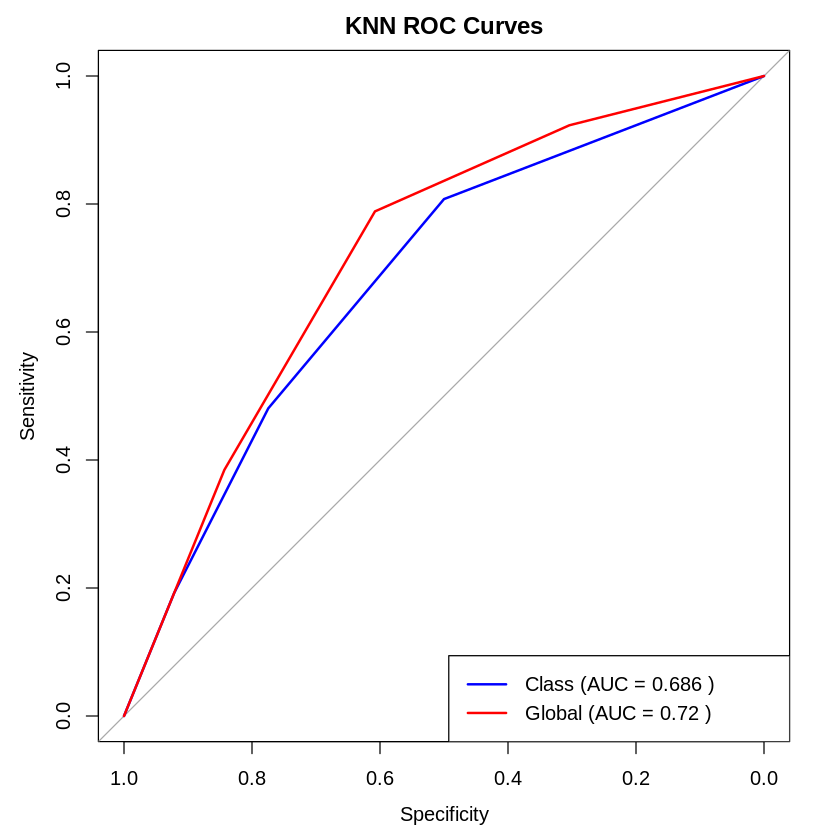

In [ ]:
# COMPARE


plot(roc_knn_class,
     col = "blue",
     lwd = 2,
     main = "KNN ROC Curves")

lines(roc_knn_global,
      col = "red",
      lwd = 2)

legend("bottomright",
       legend = c(
         paste("Class (AUC =", round(auc(roc_knn_class), 3), ")"),
         paste("Global (AUC =", round(auc(roc_knn_global), 3), ")")
       ),
       col = c("blue","red"),
       lwd = 2)

# Elbow

    Class Mean

In [ ]:
#elbow_class <- data.frame(k = k_values, accuracy = acc_c) # Turn into a dataframe
elbow_class <- data.frame(k = k_values, error = 1 - acc_c) # Turn into a dataframe

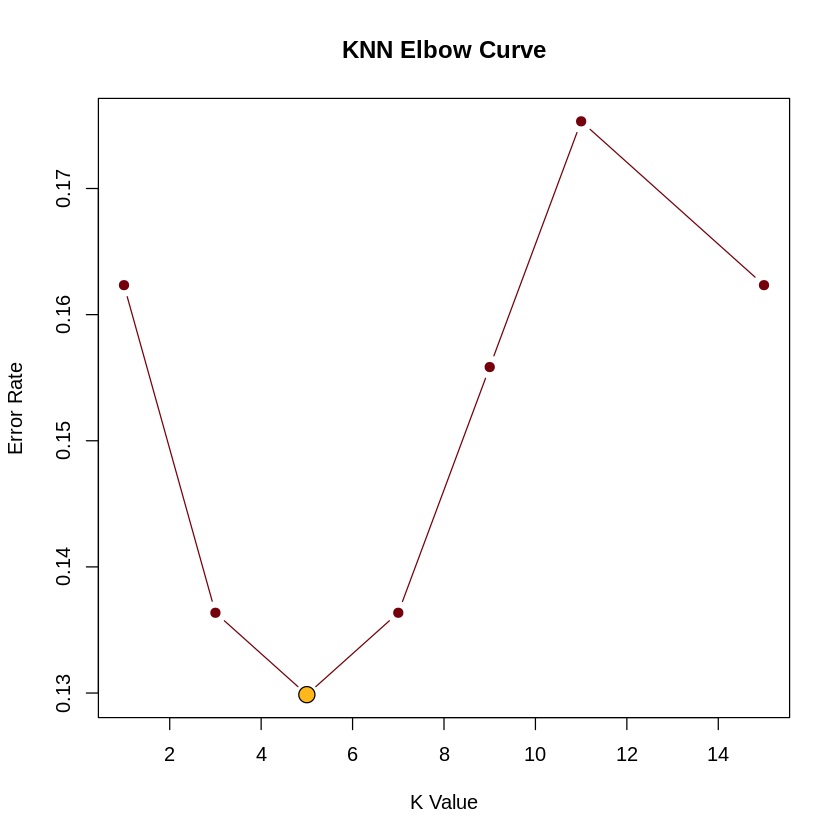

In [ ]:
plot(elbow_class$k, elbow_class$error,
     type = "b",
     xlab = "K Value",
     ylab = "Error Rate",
     col = "#73000A",      # Garnet
     main = "KNN Elbow Curve",
     pch = 19)

points(5, elbow_class$error[elbow_class$k == 5],
       pch = 21,
       bg = "#FFB81C",
       col = "black",
       cex = 1.8)

In [ ]:
# K = 5

    Global

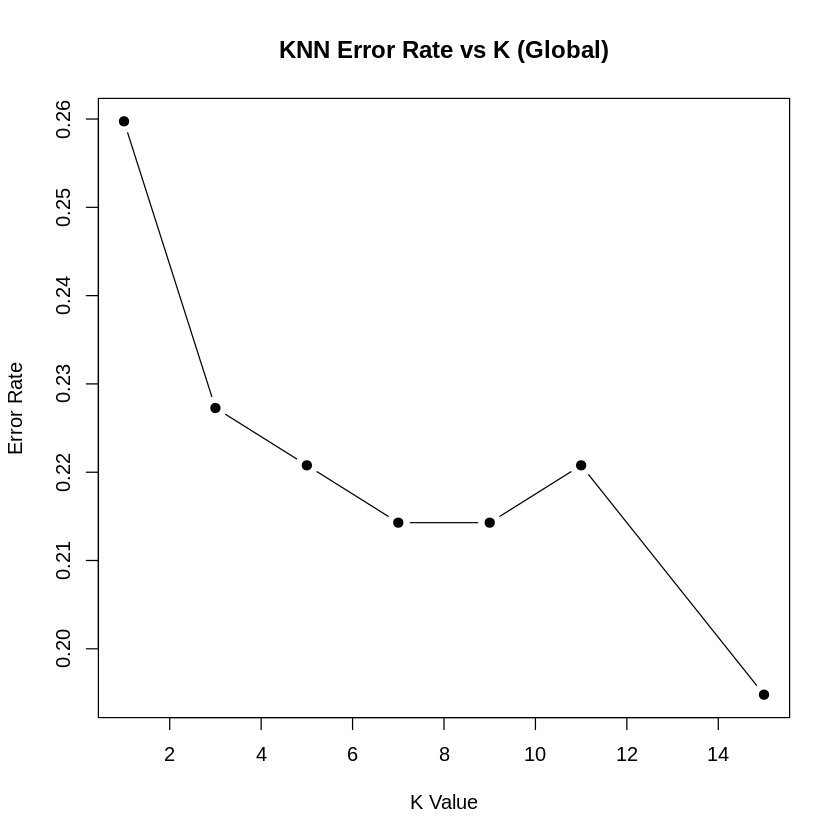

In [ ]:
elbow_global <- data.frame(k = k_values, error = 1 - acc_g) # Turn into a dataframe

plot(elbow_global$k, elbow_global$error,
     type = "b",
     xlab = "K Value",
     ylab = "Error Rate",
     main = "KNN Error Rate vs K (Global)",
     pch = 19)

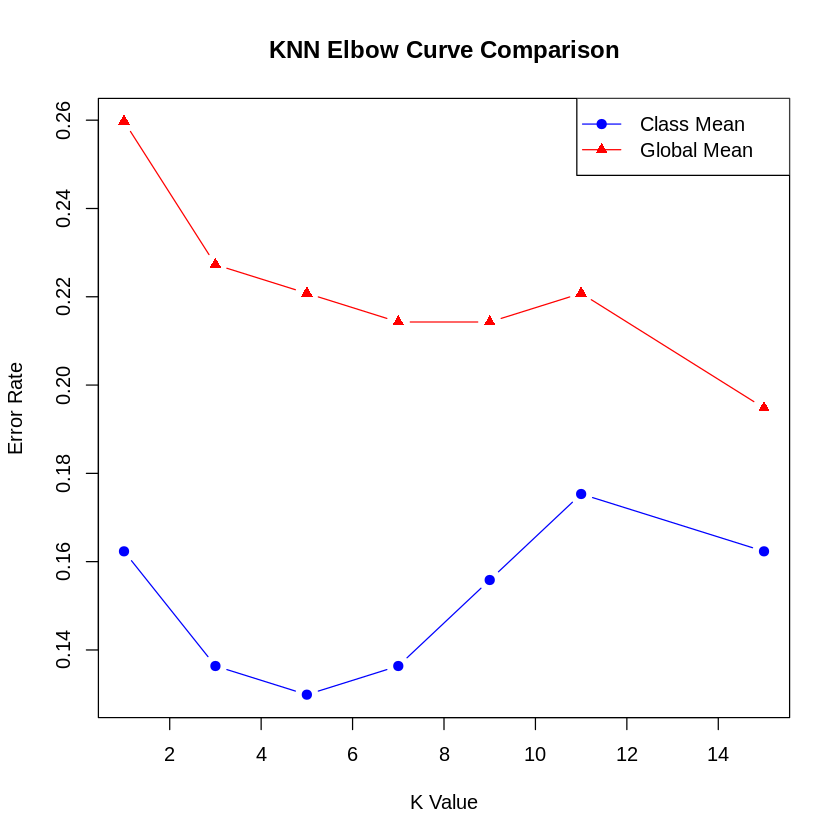

In [ ]:
plot(elbow_class$k,
     elbow_class$error,
     type = "b",
     pch = 19,
     col = "blue",
     ylim = range(c(elbow_class$error, elbow_global$error)),
     xlab = "K Value",
     ylab = "Error Rate",
     main = "KNN Elbow Curve Comparison")

lines(elbow_global$k,
      elbow_global$error,
      type = "b",
      pch = 17,
      col = "red")

legend("topright",
       legend = c("Class Mean", "Global Mean"),
       col = c("blue", "red"),
       pch = c(19, 17),
       lty = 1)

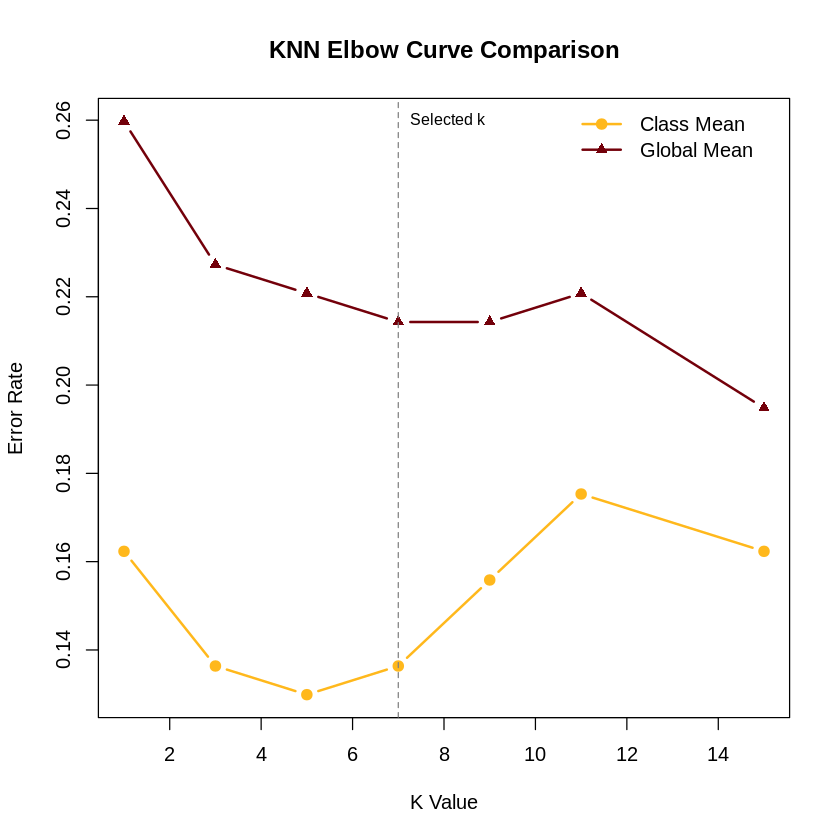

In [ ]:
plot(elbow_class$k,
     elbow_class$error,
     type = "b",
     pch = 19,
     col = "#FFB81C",      # Gold
     lwd = 2,
     ylim = range(c(elbow_class$error, elbow_global$error)),
     xlab = "K Value",
     ylab = "Error Rate",
     main = "KNN Elbow Curve Comparison")

lines(elbow_global$k,
      elbow_global$error,
      type = "b",
      pch = 17,
      col = "#73000A",      # Garnet
      lwd = 2)

legend("topright",
       legend = c("Class Mean", "Global Mean"),
       col = c("#FFB81C", "#73000A"),
       pch = c(19, 17),
       lty = 1,
       lwd = 2,
       bty = "n")

abline(v = 7, lty = 2, col = "gray50")
text(7, max(elbow_class$error, elbow_global$error),
     labels = "Selected k",
     pos = 4,
     cex = 0.8)

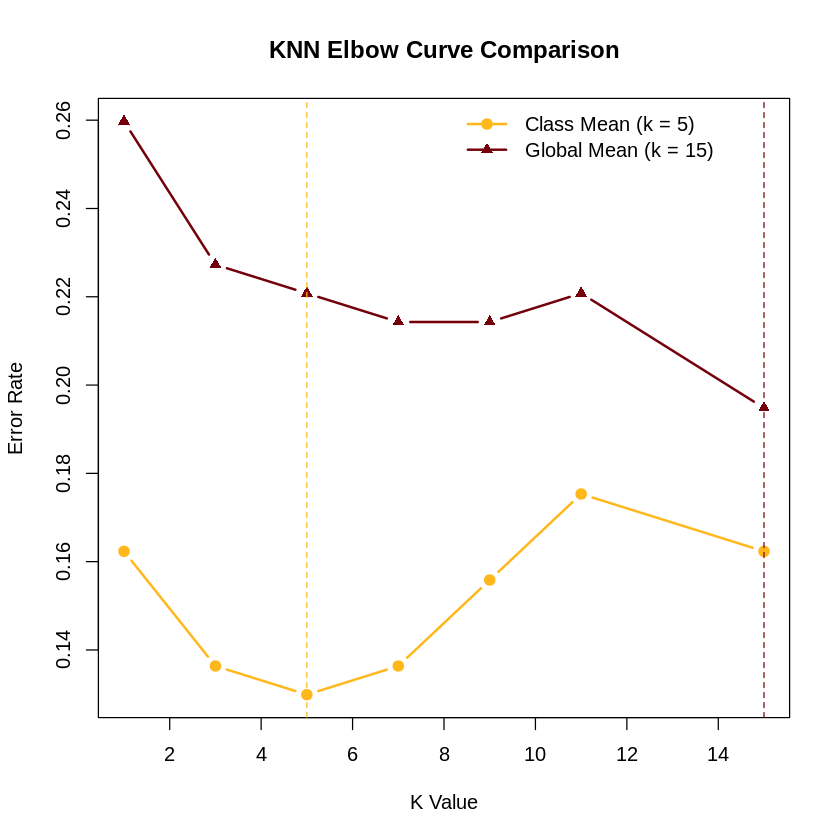

In [ ]:
plot(elbow_class$k,
     elbow_class$error,
     type = "b",
     pch = 19,
     col = "#FFB81C",      # Gold
     lwd = 2,
     ylim = range(c(elbow_class$error, elbow_global$error)),
     xlab = "K Value",
     ylab = "Error Rate",
     main = "KNN Elbow Curve Comparison")

lines(elbow_global$k,
      elbow_global$error,
      type = "b",
      pch = 17,
      col = "#73000A",      # Garnet
      lwd = 2)

# Selected k values
abline(v = 5,  lty = 2, col = "#FFB81C")
abline(v = 15, lty = 2, col = "#73000A")

legend("topright",
       legend = c("Class Mean (k = 5)",
                  "Global Mean (k = 15)"),
       col = c("#FFB81C", "#73000A"),
       pch = c(19, 17),
       lty = c(1, 1),
       lwd = 2,
       bty = "n")

# Scatter - Original

    PCA Scatter Plot

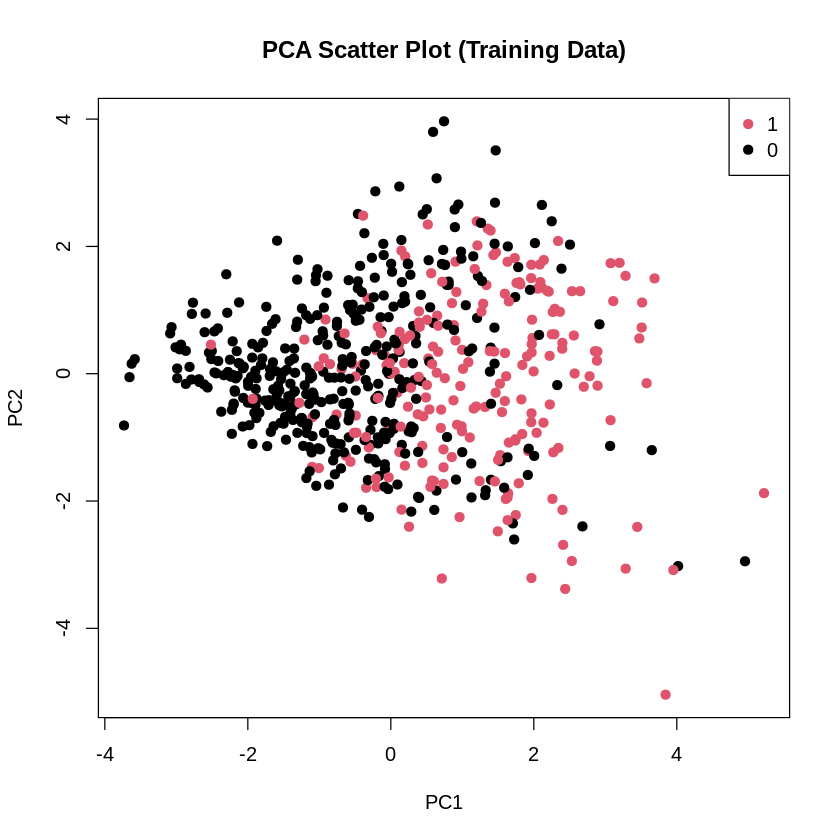

In [ ]:
pca <- prcomp(Xc_train_scaled)
pca_data <- data.frame(pca$x[,1:2])
pca_data$Outcome <- yc_train


plot(pca_data$PC1, pca_data$PC2,
     col = as.factor(pca_data$Outcome),
     pch = 19,
     xlab = "PC1",
     ylab = "PC2",
     main = "PCA Scatter Plot (Training Data)")

legend("topright",
       legend = unique(pca_data$Outcome),
       col = unique(as.factor(pca_data$Outcome)),
       pch = 19)

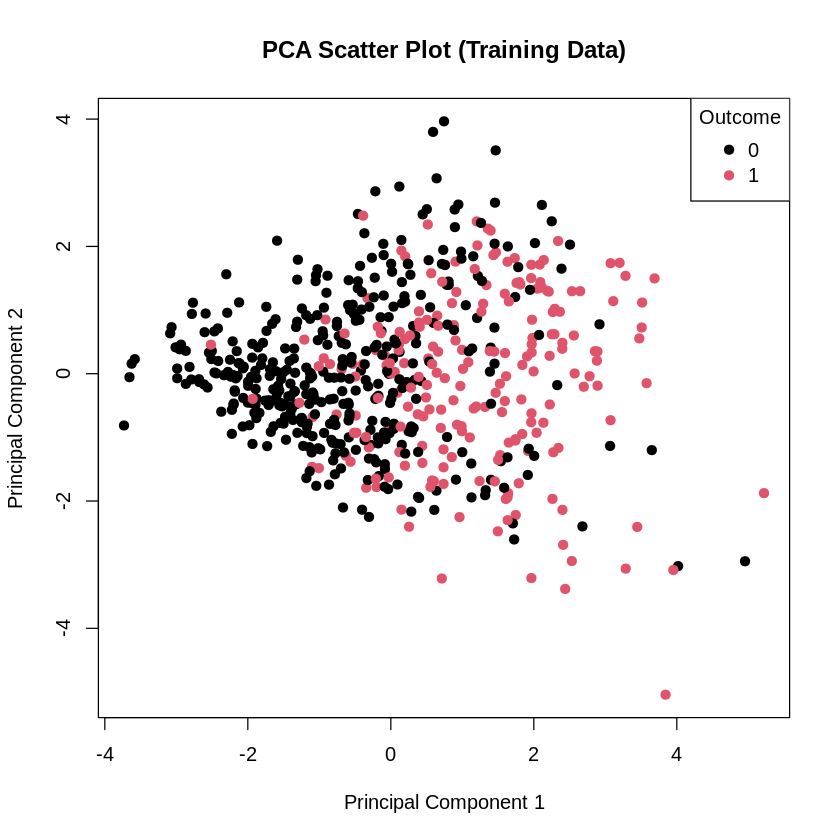

In [ ]:
pca <- prcomp(Xc_train_scaled)

pca_data <- data.frame(
    PC1 = pca$x[,1],
    PC2 = pca$x[,2],
    Outcome = yc_train
)

plot(pca_data$PC1,
     pca_data$PC2,
     col = as.factor(pca_data$Outcome),
     pch = 19,
     xlab = "Principal Component 1",
     ylab = "Principal Component 2",
     main = "PCA Scatter Plot (Training Data)")

legend("topright",
       legend = c("0", "1"),
       col = 1:2,
       pch = 19,
       title = "Outcome")

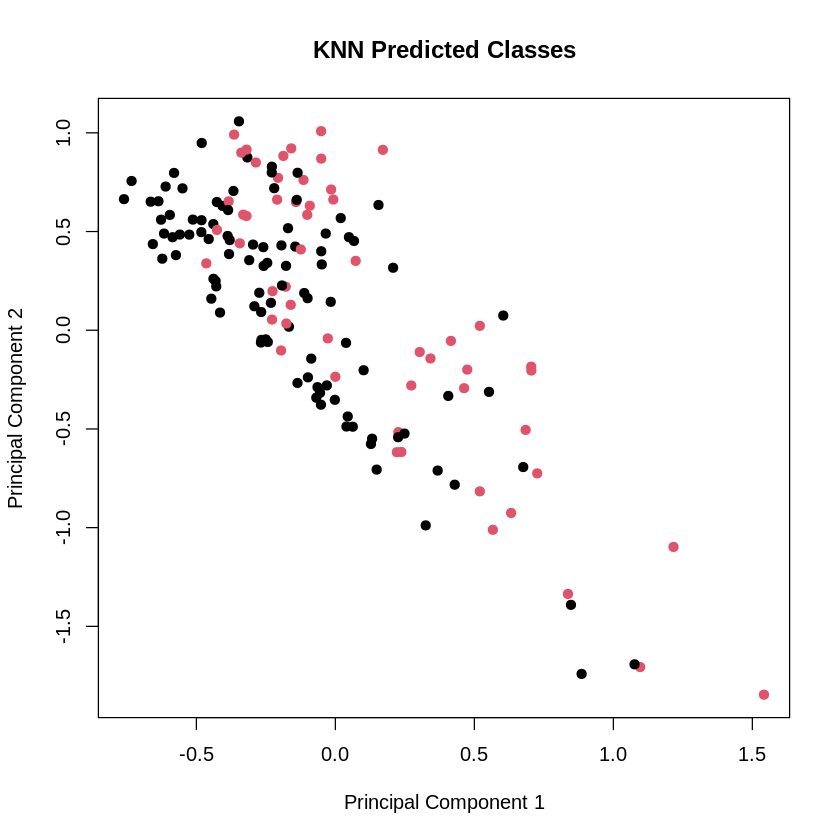

In [ ]:
test_pca <- predict(pca, Xc_test_scaled)

plot(test_pca[,1],
     test_pca[,2],
     col = as.factor(knn_class_final),
     pch = 19,
     xlab = "Principal Component 1",
     ylab = "Principal Component 2",
     main = "KNN Predicted Classes")

# Scatter - (Colors) (~)

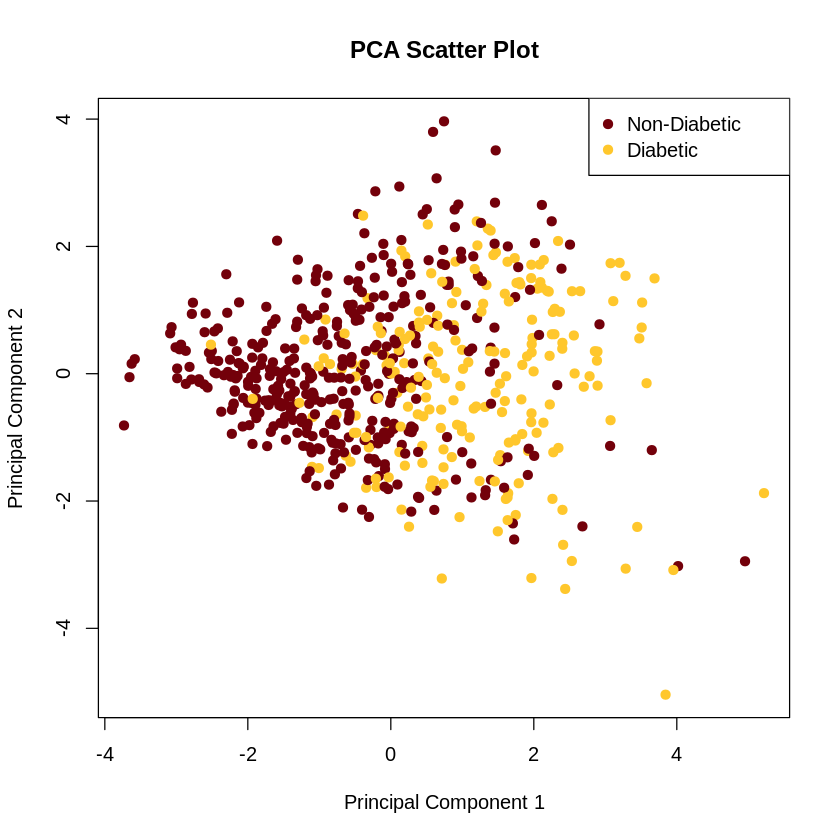

In [ ]:
colors <- c("#73000A", "#FFC72C")  # Garnet and Gold

plot(pca_data$PC1,
     pca_data$PC2,
     col = colors[pca_data$Outcome + 1],
     pch = 19,
     xlab = "Principal Component 1",
     ylab = "Principal Component 2",
     main = "PCA Scatter Plot")

legend("topright",
       legend = c("Non-Diabetic", "Diabetic"),
       col = colors,
       pch = 19)

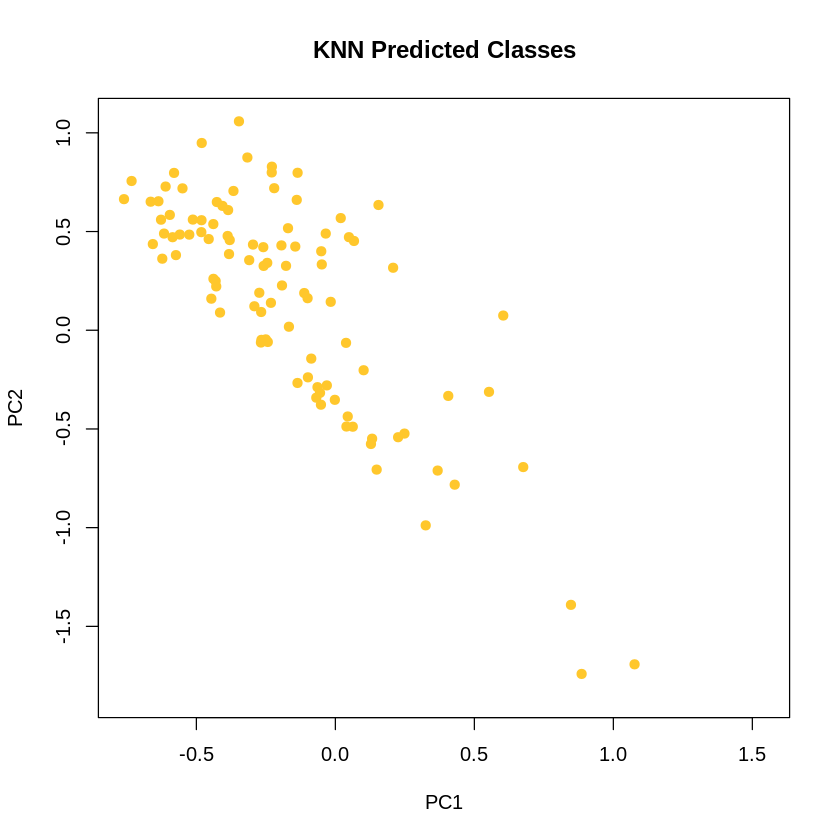

In [ ]:
test_pca <- predict(pca, Xc_test_scaled)

colors <- c("#73000A", "#FFC72C")

plot(test_pca[,1],
     test_pca[,2],
     col = colors[as.numeric(knn_class_final) + 1],
     pch = 19,
     xlab = "PC1",
     ylab = "PC2",
     main = "KNN Predicted Classes")

In [ ]:
install.packages("ggplot2")
library(ggplot2)

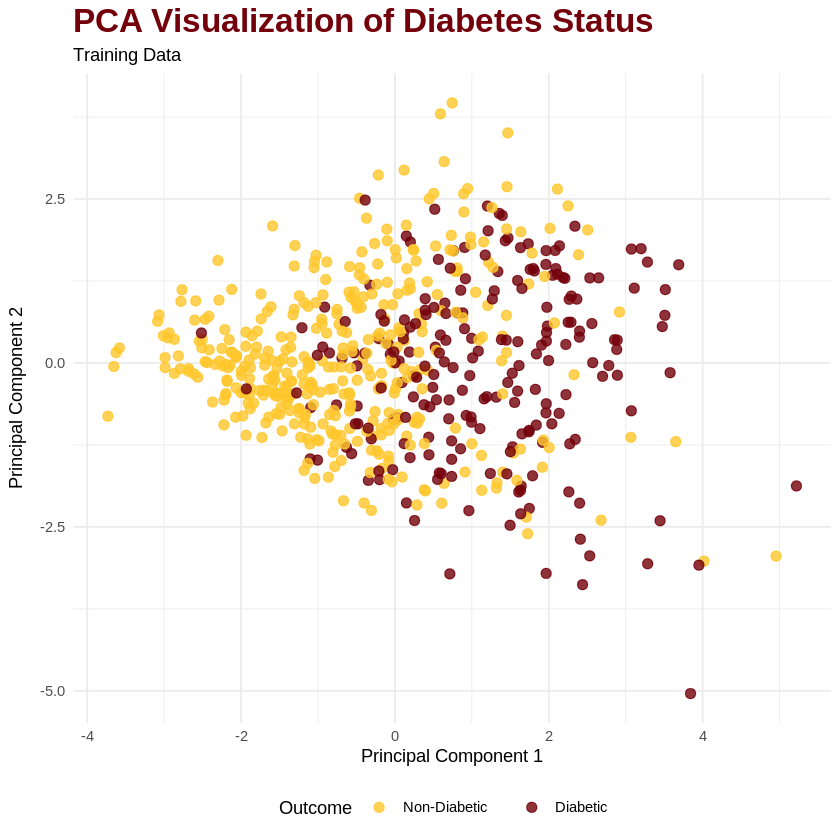

In [ ]:
pca <- prcomp(Xc_train_scaled)

plot_data <- data.frame(
    PC1 = pca$x[,1],
    PC2 = pca$x[,2],
    Outcome = factor(
        yc_train,
        levels = c(0,1),
        labels = c("Non-Diabetic","Diabetic")
    )
)

ggplot(plot_data,
       aes(PC1, PC2, color = Outcome)) +
    geom_point(size = 2.5, alpha = 0.8) +
    scale_color_manual(
        values = c(
            "Non-Diabetic" = "#FFC72C",
            "Diabetic" = "#73000A"
        )
    ) +
    labs(
        title = "PCA Visualization of Diabetes Status",
        subtitle = "Training Data",
        #title = "PCA Visualization of Diabetes Status",
        #subtitle = "Training Data Used for KNN (k = 5)",
        x = "Principal Component 1",
        y = "Principal Component 2"
    ) +
    theme_minimal() +
    theme(
        plot.title = element_text(
            face = "bold",
            color = "#73000A",
            size = 20
        ),
        legend.position = "bottom"
    )

# Scatter - Kmeans

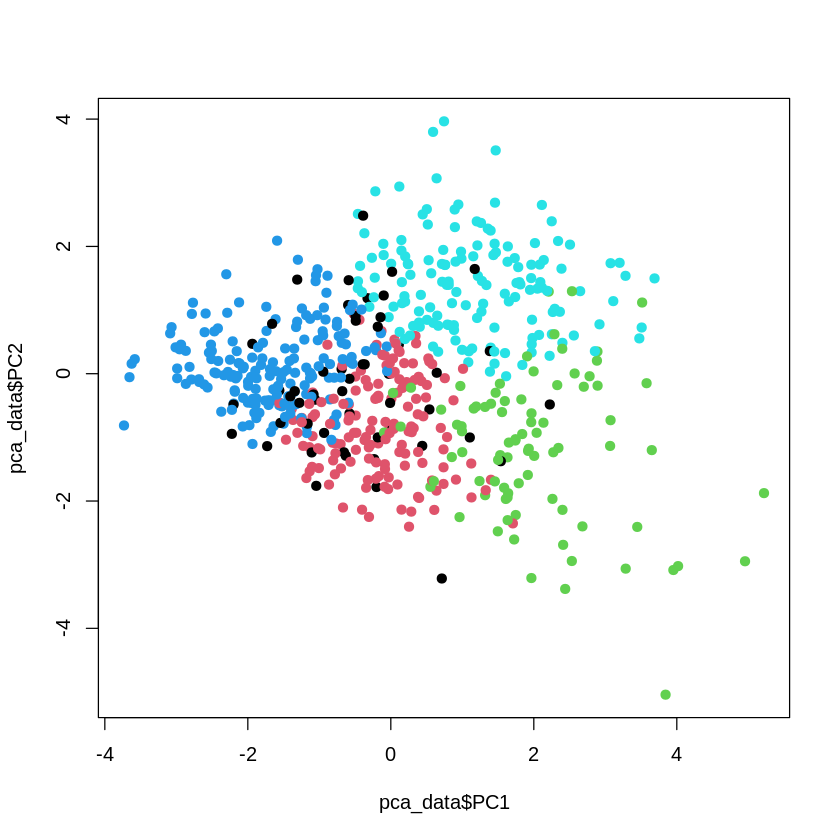

In [ ]:
km <- kmeans(Xc_train_scaled, centers = 5)

plot(pca_data$PC1,
     pca_data$PC2,
     col = km$cluster,
     pch = 19)

# KNN Notice

k = 5

does NOT mean:

    Cluster 1
    Cluster 2
    Cluster 3
    Cluster 4
    Cluster 5

Those clusters simply do not exist.

Your KNN model is:

    Training observations
    Test observations
    Five nearest neighbors for voting

# KNN Plot(s) - Old

In [ ]:
install.packages("FNN")
library(FNN)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘FNN’


The following objects are masked from ‘package:class’:

    knn, knn.cv




In [ ]:
pca <- prcomp(Xc_train_scaled)
pca_data <- data.frame(pca$x[,1:2])
pca_data$Outcome <- yc_train

In [ ]:
# Pick one test patient and draw lines to its five nearest neighbors
nn <- get.knnx(
    data = Xc_train_scaled,
    query = Xc_test_scaled[1, , drop = FALSE],
    k = 5
)

nn$nn.index

508,76,331,584,125


    All 8 variables

ERROR: Error: object 'neighbors' not found


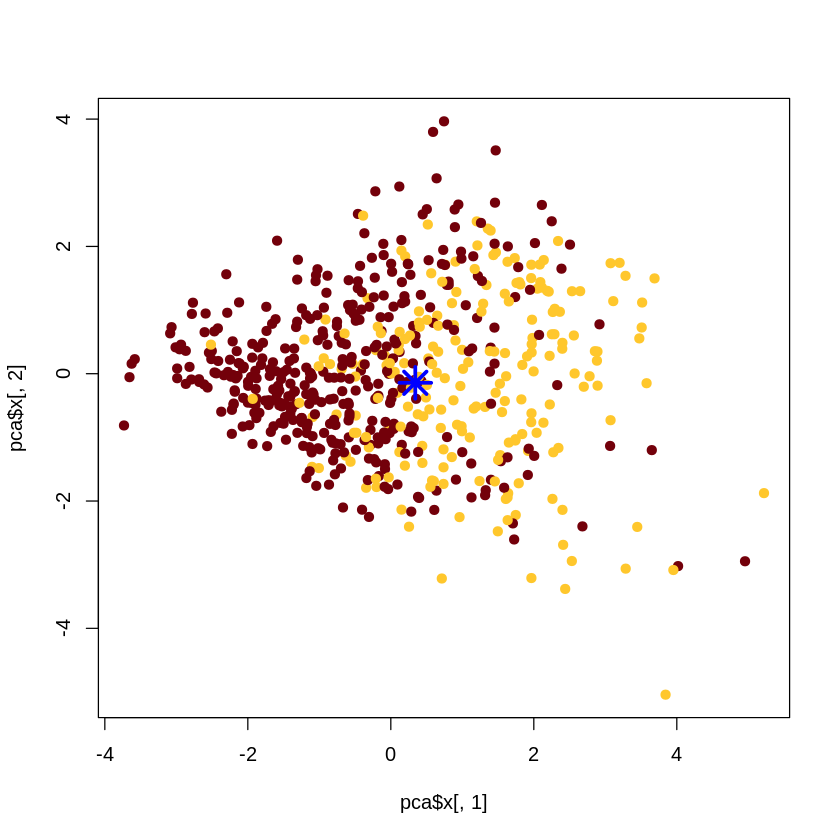

In [ ]:
test_pca <- predict(pca, Xc_test_scaled)

# Plot everything
  # Training data
plot(pca$x[,1], pca$x[,2],
     col = colors[yc_train + 1],
     pch = 19)

  # Test point
points(test_pca[1,1],
       test_pca[1,2],
       pch = 8,
       cex = 2.5,
       lwd = 3,
       col = "blue")

  # 5 Neighbors
points(pca$x[neighbors,1],
       pca$x[neighbors,2],
       pch = 1,
       cex = 2,
       lwd = 2)

# Draw Lines
neighbors <- nn$nn.index[1,]
segments(
    test_pca[1,1],
    test_pca[1,2],
    pca$x[neighbors,1],
    pca$x[neighbors,2]
)

In [ ]:
# Compute distance
nn <- get.knnx(Xc_train_scaled, Xc_test_scaled[1,,drop=FALSE], k = 5)
nn$nn.dist

1.121898,1.276676,1.337539,1.357707,1.358396


In [ ]:
# Those points are the nearest neighbors in the original 8-dimensional feature space, not necessarily in the 2-dimensional PCA plot.

    First 2 Principal Components

In [ ]:
# Fit PCA
pca <- prcomp(Xc_train_scaled)

# Keep only the first two PCs
train_pc <- pca$x[,1:2]
test_pc <- predict(pca, Xc_test_scaled)[,1:2]

# Run KNN
knn_pc <- knn(train = train_pc, test = test_pc, cl = yc_train, k = 5)

# Find neighbors
nn <- get.knnx(data = train_pc, query = test_pc[1,,drop=FALSE], k = 5)

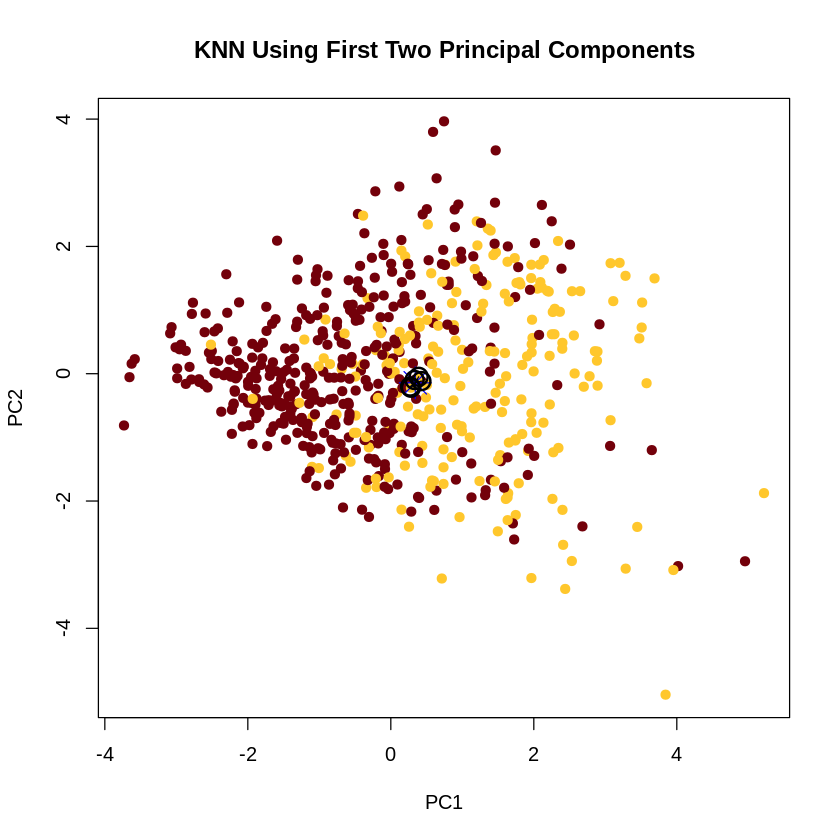

In [ ]:
# PLOT
plot(train_pc,
     col = colors[yc_train + 1],
     pch = 19,
     xlab = "PC1",
     ylab = "PC2",
     main = "KNN Using First Two Principal Components")
  # Test Point
points(test_pc[1,1],
       test_pc[1,2],
       pch = 8,
       cex = 2.5,
       col = "blue")
  # Neighbors
neighbors <- nn$nn.index[1,]
points(train_pc[neighbors,1],
       train_pc[neighbors,2],
       pch = 1,
       cex = 2,
       lwd = 2)
  # Lines
segments(
    test_pc[1,1],
    test_pc[1,2],
    train_pc[neighbors,1],
    train_pc[neighbors,2]
)

# KNN Plot(s) - New

In [ ]:
install.packages("FNN")
library(FNN)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘FNN’


The following objects are masked from ‘package:class’:

    knn, knn.cv




In [ ]:
pca <- prcomp(Xc_train_scaled)
pca_data <- data.frame(pca$x[,1:2])
pca_data$Outcome <- yc_train

In [ ]:
# Pick one test patient and draw lines to its five nearest neighbors
nn <- get.knnx(
    data = Xc_train_scaled,
    query = Xc_test_scaled[1, , drop = FALSE],
    k = 5
)
nn$nn.index
neighbors <- nn$nn.index[1,]

508,76,331,584,125


Warning message in Ops.factor(yc_train, 1):
“‘+’ not meaningful for factors”


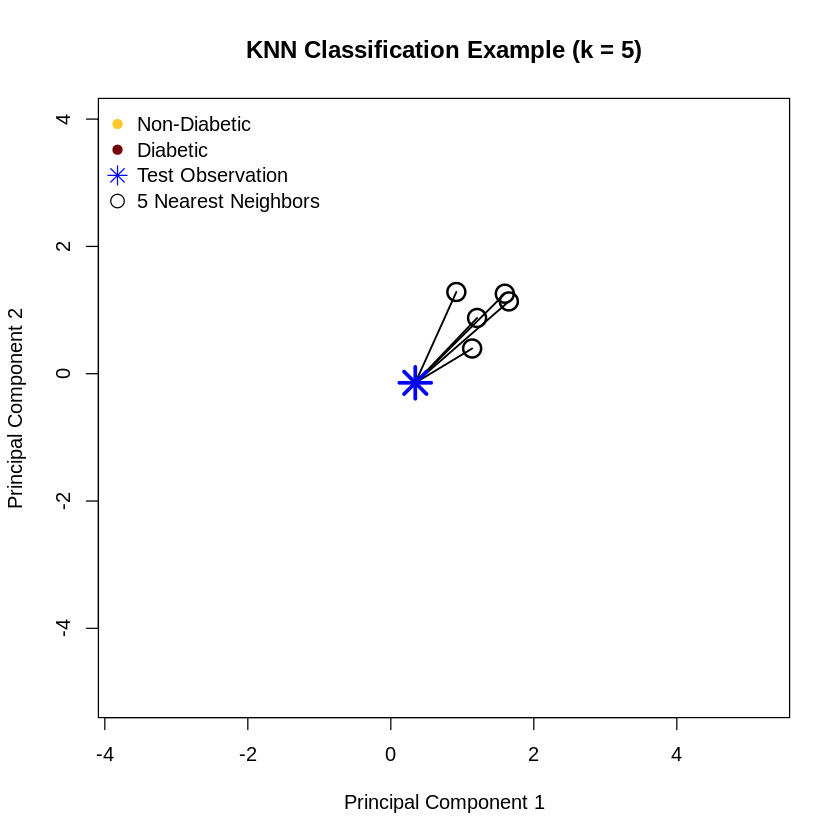

In [ ]:
# Project test data into PCA space
test_pca <- predict(pca, Xc_test_scaled)

# Plot training data
plot(
    pca$x[,1],
    pca$x[,2],
    col = colors[yc_train + 1],
    pch = 19,
    xlab = "Principal Component 1",
    ylab = "Principal Component 2",
    main = "KNN Classification Example (k = 5)"
)

# Draw lines to neighbors
segments(
    test_pca[1,1],
    test_pca[1,2],
    pca$x[neighbors,1],
    pca$x[neighbors,2],
    lwd = 1.5
)

# Highlight neighbors
points(
    pca$x[neighbors,1],
    pca$x[neighbors,2],
    pch = 1,
    cex = 2,
    lwd = 2
)

# Test patient
points(
    test_pca[1,1],
    test_pca[1,2],
    pch = 8,
    cex = 2.5,
    lwd = 3,
    col = "blue"
)

# Legend
legend(
    "topleft",
    legend = c(
        "Non-Diabetic",
        "Diabetic",
        "Test Observation",
        "5 Nearest Neighbors"
    ),
    col = c("#FFC72C", "#73000A", "blue", "black"),
    pch = c(19, 19, 8, 1),
    pt.cex = c(1, 1, 1.5, 1.5),
    bty = "n"
)